In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
from google.colab import files

uploaded = files.upload()

Saving cleaned_ecommerce_sales.csv to cleaned_ecommerce_sales.csv


In [3]:
df = pd.read_csv("cleaned_ecommerce_sales.csv")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

display(df.head())

Dataset loaded successfully!
Rows: 19
Columns: 9


,order_id,customer_name,product,category,quantity,unit_price,order_date,region,revenue
0,ORD001,Rahul Sharma,Laptop,Electronics,2.0,55000.0,2026-01-05,South,110000.0
1,ORD002,Priya Reddy,Wireless Mouse,Electronics,5.0,1200.0,2026-01-06,South,6000.0
2,ORD003,Arjun Kumar,Keyboard,Electronics,3.0,1800.0,2026-01-07,South,5400.0
3,ORD004,Unknown,Monitor,Electronics,1.0,15000.0,2026-01-15,North,15000.0
4,ORD005,Sneha Rao,Laptop,Electronics,1.0,55000.0,2026-01-09,South,55000.0


In [4]:
print("Dataset Information")
print("=" * 50)

print("\nShape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
display(df.dtypes)

print("\nMissing Values:")
display(df.isnull().sum())

Dataset Information

Shape:
(19, 9)

Columns:
['order_id', 'customer_name', 'product', 'category', 'quantity', 'unit_price', 'order_date', 'region', 'revenue']

Data Types:


,0
order_id,object
customer_name,object
product,object
category,object
quantity,float64
unit_price,float64
order_date,object
region,object
revenue,float64



Missing Values:


,0
order_id,0
customer_name,0
product,0
category,0
quantity,0
unit_price,0
order_date,0
region,0
revenue,0


In [5]:
total_revenue = df["revenue"].sum()
total_quantity = df["quantity"].sum()
total_orders = df["order_id"].nunique()
average_order_value = total_revenue / total_orders

print("KEY SALES METRICS")
print("=" * 50)
print(f"Total Revenue       : ₹{total_revenue:,.2f}")
print(f"Total Quantity Sold : {total_quantity:,.0f}")
print(f"Total Orders        : {total_orders:,}")
print(f"Average Order Value : ₹{average_order_value:,.2f}")

KEY SALES METRICS
Total Revenue       : ₹395,700.00
Total Quantity Sold : 43
Total Orders        : 19
Average Order Value : ₹20,826.32


In [6]:
category_sales = (
    df.groupby("category", as_index=False)
      .agg(
          Total_Revenue=("revenue", "sum"),
          Total_Quantity=("quantity", "sum"),
          Number_of_Orders=("order_id", "nunique")
      )
      .sort_values("Total_Revenue", ascending=False)
)

print("Sales Performance by Category")
display(category_sales)

Sales Performance by Category


,category,Total_Revenue,Total_Quantity,Number_of_Orders
0,Electronics,358100.0,37.0,15
1,Furniture,34000.0,4.0,3
2,Uncategorized,3600.0,2.0,1


In [7]:
region_sales = (
    df.groupby("region", as_index=False)
      .agg(
          Total_Revenue=("revenue", "sum"),
          Total_Quantity=("quantity", "sum"),
          Number_of_Orders=("order_id", "nunique")
      )
      .sort_values("Total_Revenue", ascending=False)
)

print("Sales Performance by Region")
display(region_sales)

Sales Performance by Region


,region,Total_Revenue,Total_Quantity,Number_of_Orders
2,South,258700.0,26.0,10
1,North,82000.0,7.0,4
3,West,34000.0,4.0,3
0,East,21000.0,6.0,2


In [8]:
product_sales = (
    df.groupby("product", as_index=False)
      .agg(
          Total_Revenue=("revenue", "sum"),
          Total_Quantity=("quantity", "sum"),
          Number_of_Orders=("order_id", "nunique")
      )
      .sort_values("Total_Revenue", ascending=False)
)

print("Product Performance")
display(product_sales)

Product Performance


,product,Total_Revenue,Total_Quantity,Number_of_Orders
2,Laptop,227000.0,6.0,4
3,Monitor,75000.0,5.0,3
4,Office Chair,34000.0,4.0,3
0,Headphones,31500.0,9.0,3
1,Keyboard,16200.0,9.0,3
5,Wireless Mouse,12000.0,10.0,3


In [9]:
top_5_products = product_sales.head(5)

print("Top 5 Products by Revenue")
display(top_5_products)

Top 5 Products by Revenue


,product,Total_Revenue,Total_Quantity,Number_of_Orders
2,Laptop,227000.0,6.0,4
3,Monitor,75000.0,5.0,3
4,Office Chair,34000.0,4.0,3
0,Headphones,31500.0,9.0,3
1,Keyboard,16200.0,9.0,3


In [10]:
df["order_date"] = pd.to_datetime(df["order_date"], errors="coerce")

df["month"] = df["order_date"].dt.to_period("M").astype(str)

monthly_sales = (
    df.groupby("month", as_index=False)
      .agg(
          Total_Revenue=("revenue", "sum"),
          Total_Quantity=("quantity", "sum"),
          Number_of_Orders=("order_id", "nunique")
      )
)

print("Monthly Sales Analysis")
display(monthly_sales)

Monthly Sales Analysis


,month,Total_Revenue,Total_Quantity,Number_of_Orders
0,2026-01,395700.0,43.0,19


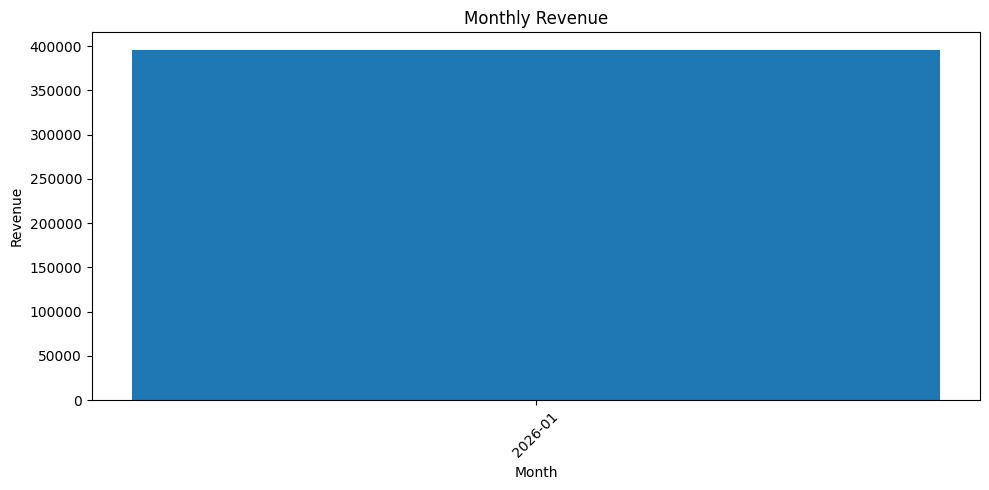

In [11]:
plt.figure(figsize=(10, 5))

plt.bar(
    monthly_sales["month"],
    monthly_sales["Total_Revenue"]
)

plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

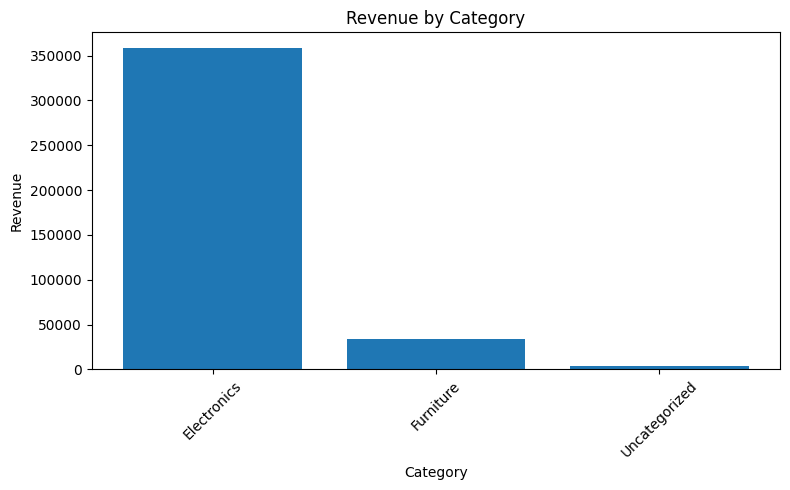

In [12]:
plt.figure(figsize=(8, 5))

plt.bar(
    category_sales["category"],
    category_sales["Total_Revenue"]
)

plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

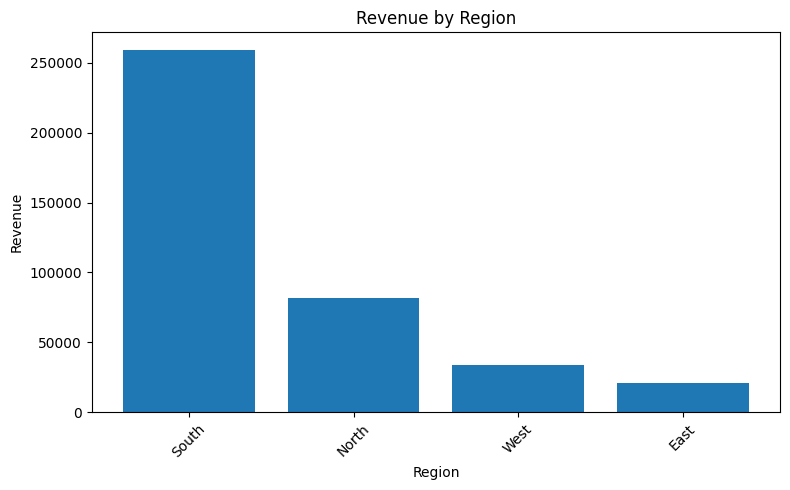

In [13]:
plt.figure(figsize=(8, 5))

plt.bar(
    region_sales["region"],
    region_sales["Total_Revenue"]
)

plt.title("Revenue by Region")
plt.xlabel("Region")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

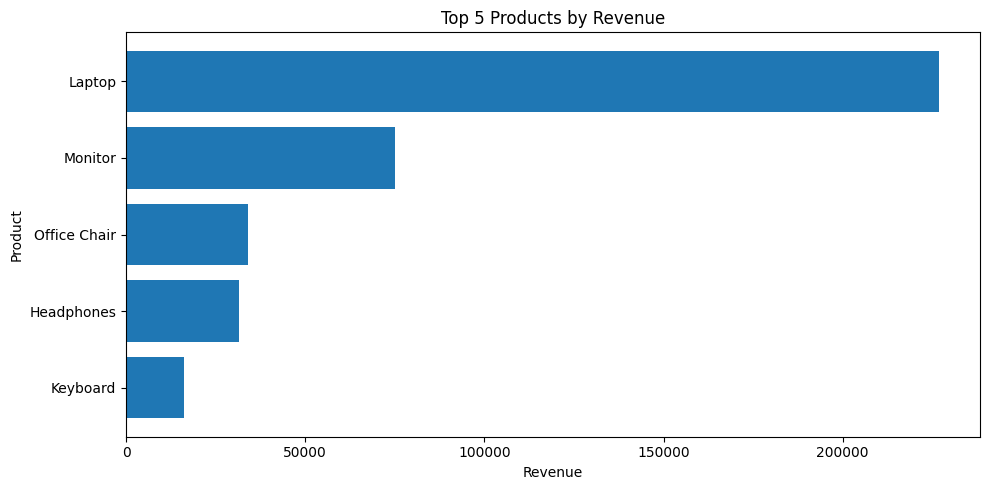

In [14]:
top_products = product_sales.head(5)

plt.figure(figsize=(10, 5))

plt.barh(
    top_products["product"],
    top_products["Total_Revenue"]
)

plt.title("Top 5 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [15]:
summary = pd.DataFrame({
    "Metric": [
        "Total Revenue",
        "Total Quantity Sold",
        "Total Orders",
        "Average Order Value"
    ],
    "Value": [
        total_revenue,
        total_quantity,
        total_orders,
        average_order_value
    ]
})

display(summary)

,Metric,Value
0,Total Revenue,395700.000000
1,Total Quantity Sold,43.000000
2,Total Orders,19.000000
3,Average Order Value,20826.315789


In [16]:
category_sales.to_csv("category_sales_analysis.csv", index=False)
region_sales.to_csv("region_sales_analysis.csv", index=False)
product_sales.to_csv("product_sales_analysis.csv", index=False)
monthly_sales.to_csv("monthly_sales_analysis.csv", index=False)
summary.to_csv("sales_analysis_summary.csv", index=False)

print("Analysis files exported successfully!")

Analysis files exported successfully!


In [17]:
assert df["revenue"].notna().all(), "Revenue contains missing values"
assert (df["revenue"] > 0).all(), "Revenue contains invalid values"
assert total_revenue > 0, "Total revenue should be positive"
assert total_quantity > 0, "Total quantity should be positive"
assert total_orders > 0, "There should be at least one order"

print("✅ ALL SALES ANALYSIS VALIDATION TESTS PASSED!")

✅ ALL SALES ANALYSIS VALIDATION TESTS PASSED!
